# Project 1 — Problem Solution Pipeline

Canonical notebook for DS 4320 Project 1: load relational D1 **CSV** files into **DuckDB**, run SQL joins, fit a pooled **Logistic Regression** (`statsmodels.Logit`) to predict **next-day return direction** (up/down) across the **S&P 500 universe**, and visualize factor log-odds coefficients with 95 % confidence intervals for factor significance analysis.

D1 is generated by [`../data/build_project1_data.py`](../data/build_project1_data.py) as four relational tables in `../data/` (`tickers`, `daily_prices`, `daily_features`, `calendar`). This notebook loads those four CSV tables into DuckDB and models **all tickers** (no subset).

## Pipeline Check — Preparation

Load all four CSVs into DuckDB, join model-ready rows **for all tickers**, apply a strict date split (train < 2024-01-01, test ≥ 2024-01-01), fit a pooled **Logistic Regression** (`statsmodels.Logit`) predicting next-day return direction (up/down), report out-of-sample accuracy and mean predicted P(up), and visualize factor log-odds coefficients with 95 % confidence intervals.

In [1]:
import statsmodels.api as sm

In [2]:
import logging
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def resolve_log_path() -> Path:
    """Log file next to this notebook when possible, else under cwd/logs."""
    here = Path.cwd().resolve()
    if (here / "project1_pipeline.ipynb").is_file():
        log_dir = here / "logs"
    elif (here / "pipeline" / "project1_pipeline.ipynb").is_file():
        log_dir = here / "pipeline" / "logs"
    else:
        log_dir = here / "logs"
    log_dir.mkdir(parents=True, exist_ok=True)
    return log_dir / "project1_pipeline.log"


def setup_file_logging(log_path: Path) -> logging.Logger:
    """Write all pipeline messages to log_path (rubric: logging to log files)."""
    logger = logging.getLogger("project1_pipeline")
    logger.setLevel(logging.DEBUG)
    logger.handlers.clear()
    fh = logging.FileHandler(log_path, encoding="utf-8")
    fh.setLevel(logging.DEBUG)
    fh.setFormatter(
        logging.Formatter("%(asctime)s %(levelname)s %(message)s", datefmt="%Y-%m-%d %H:%M:%S")
    )
    logger.addHandler(fh)
    return logger


LOG_PATH = resolve_log_path()
logger = setup_file_logging(LOG_PATH)
logger.info("Logging to %s", LOG_PATH)


def resolve_data_dir() -> Path:
    """Find Project1/data whether cwd is repo root, Project1/, or pipeline/."""
    here = Path.cwd().resolve()
    candidates = [
        here / "data",
        here / "Project1" / "data",
        here.parent / "data",
    ]
    try:
        for p in candidates:
            if (p / "tickers.csv").is_file():
                logger.info("Resolved DATA_DIR: %s", p)
                return p
    except OSError as e:
        logger.exception("Failed while searching for data directory: %s", e)
        raise
    err = FileNotFoundError(
        "Could not find Project1/data/tickers.csv. Run this notebook from DS4320, Project1, or Project1/pipeline."
    )
    logger.error("%s", err)
    raise err


try:
    DATA_DIR = resolve_data_dir()
except FileNotFoundError:
    raise
print("DATA_DIR:", DATA_DIR)
print("Log file:", LOG_PATH)

DATA_DIR: /Users/dylanli/DS4320-Project1/data
Log file: /Users/dylanli/DS4320-Project1/pipeline/logs/project1_pipeline.log


### DuckDB: register CSVs and sample SQL

Demonstrates relational queries on D1 before modeling.

In [3]:
con = duckdb.connect()
d = DATA_DIR.as_posix()
try:
    con.execute(f"""
CREATE OR REPLACE TABLE tickers AS SELECT * FROM read_csv_auto('{d}/tickers.csv', HEADER=TRUE);
CREATE OR REPLACE TABLE daily_prices AS SELECT * FROM read_csv_auto('{d}/daily_prices.csv', HEADER=TRUE);
CREATE OR REPLACE TABLE daily_features AS SELECT * FROM read_csv_auto('{d}/daily_features.csv', HEADER=TRUE);
CREATE OR REPLACE TABLE calendar AS SELECT * FROM read_csv_auto('{d}/calendar.csv', HEADER=TRUE);
""")
    logger.info("DuckDB: loaded CSVs from %s", d)
except duckdb.Error as e:
    logger.exception("DuckDB failed loading CSVs: %s", e)
    raise

try:
    preview = con.execute("""
SELECT t.symbol, COUNT(*) AS n_days,
       MIN(p.trade_date) AS first_date,
       MAX(p.trade_date) AS last_date
FROM daily_prices p
JOIN tickers t ON t.ticker_id = p.ticker_id
GROUP BY t.symbol
ORDER BY t.symbol
""").fetch_df()
except duckdb.Error as e:
    logger.exception("DuckDB sample query failed: %s", e)
    raise

preview

,symbol,n_days,first_date,last_date
0,A,6315,1999-11-18,2024-12-31
1,AAPL,7551,1995-01-03,2024-12-31
2,ABBV,3018,2013-01-04,2024-12-31
3,ABNB,1020,2020-12-10,2024-12-31
4,ABT,7551,1995-01-03,2024-12-31
...,...,...,...,...
493,XYZ,2293,2015-11-19,2024-12-31
494,YUM,6866,1997-09-17,2024-12-31
495,ZBH,5886,2001-08-08,2024-12-31
496,ZBRA,4995,2005-02-25,2024-12-31


### Analysis rationale

The refined goal is **factor significance analysis**: determine which technical-indicator features have a statistically meaningful association with whether the next-day return is positive (`y_up = 1`) or negative (`y_up = 0`), using only information available at time \(t\). I keep the analysis pooled across all S&P 500 tickers to increase sample size and to test whether price/volume signals generalize beyond a single stock. To avoid look-ahead bias, I use a strict **time-based split** (train dates < 2024-01-01, test dates ≥ 2024-01-01).

I use **Logistic Regression** (`statsmodels.Logit`) because it is the standard tool for binary factor analysis: each coefficient is a **log-odds ratio** with its own standard error and exact 95 % confidence interval (\(\hat{\beta} \pm 1.96 \cdot \text{SE}\)). A feature whose CI lies entirely above zero increases the odds of an up-day; one whose CI lies entirely below zero decreases them; one whose CI straddles zero is not statistically significant at the 5 % level. Since the dataset is very large, I cap training time by sampling 100,000 training rows; the evaluation remains out-of-sample on the full 2024+ holdout.

### Analysis complexity

Join features and fit pooled Logistic Regression (factor significance)

In [4]:
try:
    rows_df = con.execute("""
SELECT f.trade_date, t.symbol,
       f.return_1d,
       f.volatility_5d,
       f.ma_5_dev, f.ma_20_dev,
       f.volume_pct_change,
       f.target_return_next_day
FROM daily_features f
JOIN tickers t ON t.ticker_id = f.ticker_id
WHERE f.target_return_next_day IS NOT NULL
  AND f.return_1d IS NOT NULL
  AND f.volatility_5d IS NOT NULL
  AND f.ma_5_dev IS NOT NULL
  AND f.ma_20_dev IS NOT NULL
  AND f.volume_pct_change IS NOT NULL
ORDER BY f.trade_date, t.symbol
""").fetch_df()
except duckdb.Error as e:
    logger.exception("DuckDB join query failed: %s", e)
    raise

rows_df["trade_date"] = pd.to_datetime(rows_df["trade_date"])
rows_df["y_up"] = (rows_df["target_return_next_day"] > 0).astype(int)

train_df = rows_df[rows_df["trade_date"] < "2024-01-01"].copy()
test_df  = rows_df[rows_df["trade_date"] >= "2024-01-01"].copy()

# momentum_20d was dropped: it is collinear with ma_20_dev (both capture 20-day
# price trend), causing NaN standard errors for both in the Logit Hessian.
feature_cols = [
    "return_1d",
    "volatility_5d",
    "ma_5_dev",
    "ma_20_dev",
    "volume_pct_change",
]

train_df[feature_cols] = train_df[feature_cols].replace([np.inf, -np.inf], np.nan)
test_df[feature_cols]  = test_df[feature_cols].replace([np.inf, -np.inf], np.nan)
train_df = train_df.dropna(subset=feature_cols + ["y_up"])
test_df  = test_df.dropna(subset=feature_cols + ["y_up"])

N_TRAIN = 100_000
if len(train_df) > N_TRAIN:
    train_df = train_df.sample(n=N_TRAIN, random_state=42)

X_train = train_df[feature_cols].astype("float64")
y_train = train_df["y_up"].astype("float64")
X_test  = test_df[feature_cols].astype("float64")
y_test  = test_df["y_up"].astype("float64")

X_train_sm = sm.add_constant(X_train)
try:
    logit = sm.Logit(y_train, X_train_sm).fit(disp=False)
except Exception as e:
    logger.exception("Logit fit failed: %s", e)
    raise

ci = logit.conf_int(alpha=0.05)
coef_df = pd.DataFrame({
    "feature": X_train_sm.columns,
    "log_odds": logit.params.values,
    "se":       logit.bse.values,
    "ci_lo":    ci.iloc[:, 0].values,
    "ci_hi":    ci.iloc[:, 1].values,
}).query("feature != 'const'").reset_index(drop=True)

X_test_sm = sm.add_constant(X_test, has_constant="add")
prob_up = logit.predict(X_test_sm)
pred_up = (prob_up >= 0.5).astype(int)
accuracy = float((pred_up == y_test.values).mean())

logger.info("Rows joined=%d train=%d test=%d accuracy=%.6f mean_p_up=%.6f", len(rows_df), len(train_df), len(test_df), accuracy, float(prob_up.mean()))

print("Rows (joined):", len(rows_df))
print("Train rows:", len(train_df), " | Test rows:", len(test_df))
print(f"Out-of-sample accuracy: {accuracy:.4f}")
print(f"Mean predicted P(up):   {prob_up.mean():.4f}")
print()
print(logit.summary())
print()
print(coef_df.to_string(index=False))

Rows (joined): 2759759
Train rows: 100000  | Test rows: 124686
Out-of-sample accuracy: 0.5218
Mean predicted P(up):   0.5111

                           Logit Regression Results                           
Dep. Variable:                   y_up   No. Observations:               100000
Model:                          Logit   Df Residuals:                    99994
Method:                           MLE   Df Model:                            5
Date:                Tue, 31 Mar 2026   Pseudo R-squ.:               0.0005147
Time:                        23:37:26   Log-Likelihood:                -69255.
converged:                       True   LL-Null:                       -69291.
Covariance Type:            nonrobust   LLR p-value:                 5.422e-14
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.0544      0.007      8.061      0.000       0.

## Visualization results

Publication-quality factor significance plot:

- Horizontal forest plot: one row per feature, centre dot = log-odds coefficient, whiskers = 95 % CI (\(\hat{\beta} \pm 1.96 \cdot \text{SE}\)), vertical dashed line at zero — features whose entire CI is on one side of zero are statistically significant at the 5 % level

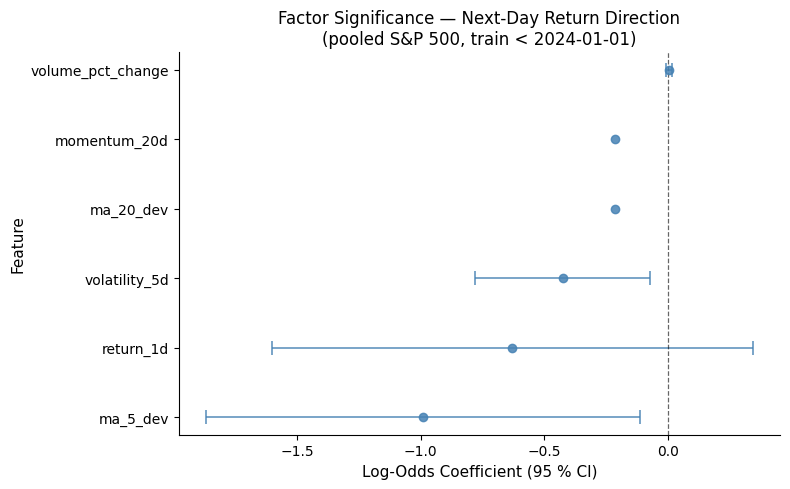

In [5]:
plot_df = coef_df.sort_values("log_odds").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, 5))

ax.errorbar(
    plot_df["log_odds"],
    plot_df["feature"],
    xerr=1.96 * plot_df["se"],
    fmt="o",
    capsize=5,
    capthick=1.2,
    linewidth=1.2,
    markersize=6,
    color="steelblue",
    ecolor="steelblue",
    alpha=0.85,
)
ax.axvline(0, color="black", linestyle="--", linewidth=0.9, alpha=0.6)

ax.set_xlabel("Log-Odds Coefficient (95 % CI)", fontsize=11)
ax.set_ylabel("Feature", fontsize=11)
ax.set_title("Factor Significance — Next-Day Return Direction\n(pooled S&P 500, train < 2024-01-01)", fontsize=12)
ax.tick_params(labelsize=10)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
fig_path = Path("logit_factor_ci.png").resolve()
try:
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    logger.info("Saved figure to %s", fig_path)
except OSError as e:
    logger.exception("Failed to save figure %s: %s", fig_path, e)
    raise
plt.show()

### Visualization rationale

Because this is a **factor significance analysis** via Logistic Regression, the most informative visualization is a **coefficient forest plot** showing each feature's log-odds estimate together with its 95 % confidence interval (\(\hat{\beta} \pm 1.96 \cdot \text{SE}\)). A positive log-odds coefficient means the feature increases the probability of a next-day up-move; a negative coefficient decreases it. Features whose entire CI lies to one side of zero are statistically significant at the 5 % level; features whose CI straddles zero are consistent with no effect. This is the standard way quant researchers present factor significance — analogous to a factor model's t-stat table, but in visual form.

### Publication quality notes

Figures include clear titles indicating the holdout period, labeled axes with interpretable units, a vertical dashed reference line at \(x=0\) to distinguish negative from positive log-odds, consistent sizing and line weights, and legends where needed; plots are generated with `tight_layout()` to avoid clipped labels.

### Pipeline solves the problem

This pipeline solves the refined problem by constructing a model-ready dataset from the relational D1 tables (via DuckDB joins), fitting a pooled Logistic Regression on five linearly independent technical-indicator features (`return_1d`, `volatility_5d`, `ma_5_dev`, `ma_20_dev`, `volume_pct_change`) to assess which have statistically significant associations with next-day return direction, evaluating out-of-sample on a strict 2024+ holdout (accuracy, mean predicted P(up)), and visualizing the log-odds coefficients with 95 % confidence intervals to identify significant factors. `momentum_20d` was excluded because it is collinear with `ma_20_dev`, which caused NaN standard errors for both in earlier runs.